<a href="https://colab.research.google.com/github/guzik1234/DataScienceCwiczenia/blob/main/python_pandas/Amazon%20Revievs.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [4]:
import numpy as np
import pandas as pd

In [6]:
df = pd.read_csv('Consumer_Reviews_Amazon.csv', engine='python', index_col=0)

In [7]:
df.describe()

,reviews.id,reviews.numHelpful,reviews.rating
count,2.900000e+01,5000.000000,5000.000000
mean,1.858740e+08,0.312400,4.596800
std,2.084040e+07,3.111582,0.731804
min,1.082112e+08,0.000000,1.000000
25%,1.851185e+08,0.000000,4.000000
50%,1.880757e+08,0.000000,5.000000
75%,1.981949e+08,0.000000,5.000000
max,2.027812e+08,105.000000,5.000000


In [11]:
for col in df.columns:
    print(col)
df.columns = [col for col in df.columns]

dateAdded
dateUpdated
name
asins
brand
categories
primaryCategories
imageURLs
keys
manufacturer
manufacturerNumber
reviews_date
reviews_dateAdded
reviews_dateSeen
reviews_doRecommend
reviews_id
reviews_numHelpful
reviews_rating
reviews_sourceURLs
reviews_text
reviews_title
reviews_username
sourceURLs


In [12]:
df.columns = [col.replace('.', '_') for col in df.columns]

In [14]:
df = df[['name', 'primaryCategories', 'reviews_rating', 'reviews_text']]
df.columns = ['name', 'category', 'rating', 'text']
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 5000 entries, AVqVGZNvQMlgsOJE6eUY to AVqkIdZiv8e3D1O-leaJ
Data columns (total 4 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   name      5000 non-null   object
 1   category  5000 non-null   object
 2   rating    5000 non-null   int64 
 3   text      5000 non-null   object
dtypes: int64(1), object(3)
memory usage: 324.4+ KB


In [15]:
df.to_csv('reviews_clean.csv')

In [16]:
import seaborn as sns

In [18]:
sns.set()
df= pd.read_csv('reviews_clean.csv', index_col=0)

<Axes: ylabel='count'>

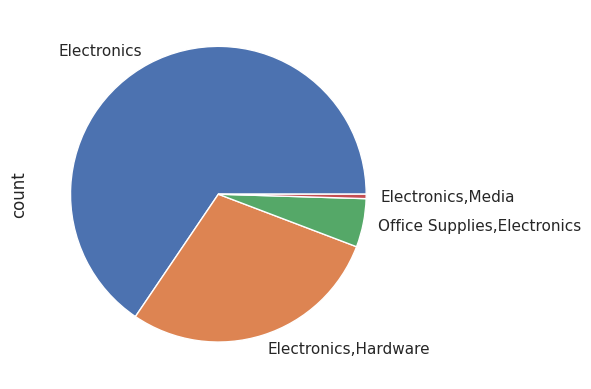

In [20]:
df['category'].value_counts().plot(kind='pie')

<Axes: title={'center': 'Frequency'}, xlabel='rating'>

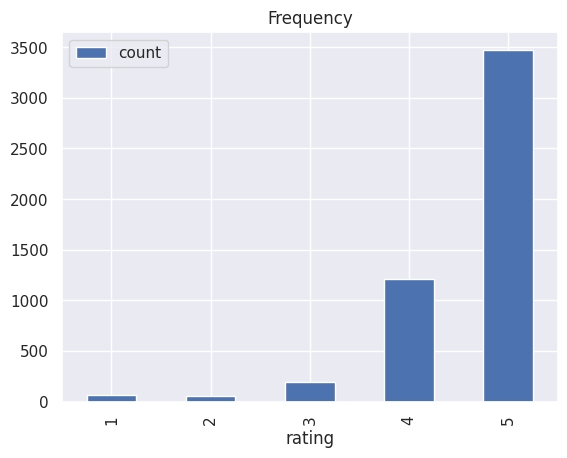

In [25]:
df['rating'].value_counts().sort_index().plot(kind='bar', legend=True, title='Frequency')

<Axes: xlabel='name'>

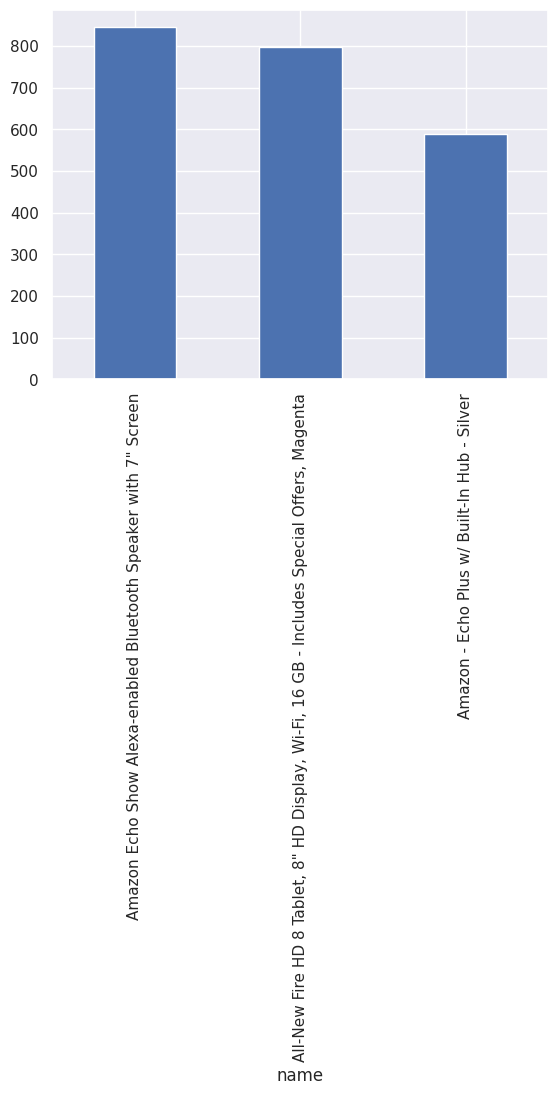

In [30]:
tmp = df.groupby('name').count()['rating'].rename('count').nlargest(3).plot(kind='bar')
tmp

In [34]:
df.groupby('name')['rating'].agg('mean').rename('avg_rating').reset_index().nlargest(3, 'avg_rating')

,name,avg_rating
10,Amazon Fire TV with 4K Ultra HD and Alexa Voic...,5.000000
8,Amazon 9W PowerFast Official OEM USB Charger a...,4.863636
21,Kindle Oasis E-reader with Leather Charging Co...,4.820513


In [35]:
df.groupby('name')['rating'].agg('mean').rename('avg_rating').reset_index().nsmallest(3, 'avg_rating')

,name,avg_rating
1,"All-New Fire HD 8 Tablet, 8 HD Display, Wi-Fi,...",4.400000
11,"Amazon Kindle E-Reader 6"" Wifi (8th Generation...",4.406250
19,"Fire Tablet, 7 Display, Wi-Fi, 16 GB - Include...",4.460916
